# Anomaly Machine Learning Model- Second attempt

### This script takes the data we created in the concardance scripts, merges BRCA 1 and 2, then attempts to predict Pathogenic Variants as anomalies. I used the Clinvar Significance labels from concordance script to test how well the model performed. 

Predicting the ClinVar significance labels allowed the use of the original REVEL scores and PolyPhen-2 prediction results without significant concern for data leakage. Because REVEL and PolyPhen-2 predictions only aligned approximately 65% of the time, their outputs were sufficiently distinct to be included as separate features in the models below.

### Two Types of anomaly models were created - Isolation Forest and Local Outlier Factor

In [1]:
#importing packages needed
import pandas as pd
import numpy as np

In [ ]:
#uploading the data
BRCAVs = pd.read_csv("C:/Users/knigh/Documents/UHD MSDA/Capstone/ML Model/2026_BRCA1and2_ConcordanceLabels_22.csv")
print(BRCAVs.shape)
BRCAVs.head()
#removing the data to comply with All of Us data user policies.

In [3]:
#grabbing the list of columns names for further data wrangling
BRCAVs.columns

Index(['locus', 'alleles', 'qc_AC', 'qc_AF', 'qc_AN', 'call_rate', 'n_het',
       'info_AC', 'info_AF', 'info_AN', 'vid', 'contig', 'position',
       'consequence', 'clinvar_classification', 'variant_type', 'ref_allele',
       'alt_allele', 'gvs_all_ac', 'gvs_all_an', 'gvs_all_af', 'gvs_all_sc',
       'dbsnp_rsid', 'revel', 'vid_alt', 'gvs_max_subpop', 'aa_change',
       'transcript', 'gene_symbol', 'gvs_max_ac', 'gvs_max_sc', 'gvs_max_an',
       'gnomad_max_subpop', 'protein_id', 'hgvsp', 'aa_extract', 'AA1', 'AA2',
       'Protein', 'Position', 'Ref_AA', 'Alt_AA',
       '(HumDiv) Polyphen Significance(S1)', 'Score(S1)', 'Sensitivity(S1)',
       'FPR Score(S1)', 'Specificity(S1)',
       '(HumDiv) Polyphen Significance(S2)', 'Score(S2)', 'Sensitivity(S2)',
       'FPR Score(S2)', 'Specificity(S2)', 'clinvar_CL', 'revel_CL',
       '(HumDiv) Polyphen Significance(S1)_CL',
       '(HumDiv) Polyphen Significance(S2)_CL'],
      dtype='object')

In [ ]:
#dropping un-needed columns like unique identifers, labels, redunant, and non-useful information
#following most of the same columns dropped in the classification models
BRCA_MD1 = BRCAVs.drop(columns=['locus', 'alleles', 'qc_AC', 'qc_AN', 'info_AC', 'info_AN', 'vid', 'contig', 'position',
       'consequence', 'variant_type', 'gvs_all_ac', 'gvs_all_an','Position',
       'dbsnp_rsid', 'vid_alt', 'aa_change','transcript', 'gene_symbol', 'gnomad_max_subpop', 'protein_id', 'hgvsp', 'aa_extract', 'AA1', 'AA2',
       '(HumDiv) Polyphen Significance(S1)', 'Score(S1)', 'Sensitivity(S1)',
       'FPR Score(S1)', 'Specificity(S1)','clinvar_CL', 'revel_CL',
       '(HumDiv) Polyphen Significance(S1)_CL',
       '(HumDiv) Polyphen Significance(S2)_CL'])

BRCA_MD1.head()
#No unique idenitifers present for participant data

,qc_AF,call_rate,n_het,info_AF,clinvar_classification,ref_allele,alt_allele,gvs_all_af,gvs_all_sc,revel,...,gvs_max_sc,gvs_max_an,Protein,Ref_AA,Alt_AA,(HumDiv) Polyphen Significance(S2),Score(S2),Sensitivity(S2),FPR Score(S2),Specificity(S2)
0,"[0.999993679047306, 6.320952693990038e-06]",0.999949,1,[1.20537694547839e-06],not provided,G,T,0.000001,1,0.562,...,1,143702,P38398,T,N,Possibly Damaging,0.882,0.0644,0.824,0.176
1,"[0.9999936792071198, 6.3207928802589e-06]",0.999975,1,[2.4107248326354284e-06],uncertain significance,C,T,0.000002,2,0.690,...,1,51006,P38398,V,M,Benign,0.063,0.16,0.937,0.063
2,"[0.999981037141918, 1.8962858081970115e-05]",0.999949,3,[3.6161482717222026e-06],"uncertain significance, likely pathogenic, pat...",C,T,0.000004,3,0.862,...,3,143700,P38398,G,D,Probably Damaging,0.997,0.0167,0.409,0.591
3,"[0.9999936792071198, 6.3207928802589e-06]",0.999975,1,[1.2053711337720885e-06],"uncertain significance, likely pathogenic, not...",C,T,0.000001,1,0.789,...,1,143704,P38398,C,Y,Possibly Damaging,0.917,0.0597,0.812,0.188
4,"[0.999981035703449, 1.89642965510266e-05]",0.999874,3,[3.6165057321615856e-06],"uncertain significance, pathogenic, not provided",A,T,0.000004,3,0.812,...,3,143688,P38398,C,S,Probably Damaging,0.986,0.0368,0.736,0.264


## Exploring the Data

In [5]:
#looking at the shape of the data
BRCA_MD1.shape

(1354, 22)

In [6]:
#looking at the meta data for the dataframe to see the data types of each variable
BRCA_MD1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1354 entries, 0 to 1353
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   qc_AF                               1354 non-null   object 
 1   call_rate                           1354 non-null   float64
 2   n_het                               1354 non-null   int64  
 3   info_AF                             1354 non-null   object 
 4   clinvar_classification              1261 non-null   object 
 5   ref_allele                          1354 non-null   object 
 6   alt_allele                          1354 non-null   object 
 7   gvs_all_af                          1354 non-null   float64
 8   gvs_all_sc                          1354 non-null   int64  
 9   revel                               1354 non-null   float64
 10  gvs_max_subpop                      1354 non-null   object 
 11  gvs_max_ac                          1354 no

In [7]:
#looking at an overview of the numeric variables
BRCA_MD1.describe()

,call_rate,n_het,gvs_all_af,gvs_all_sc,revel,gvs_max_ac,gvs_max_sc,gvs_max_an
count,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000
mean,0.999815,187.815362,0.002268,1396.242245,0.359276,288.415805,235.062038,142707.589365
std,0.000750,2171.141622,0.033532,17676.143486,0.207359,3896.402846,2567.682665,107683.321617
min,0.979888,0.000000,0.000001,1.000000,0.010000,1.000000,1.000000,1610.000000
25%,0.999861,1.000000,0.000002,2.000000,0.183250,1.000000,1.000000,51008.000000
50%,0.999918,2.000000,0.000006,5.000000,0.330000,2.000000,2.000000,143694.000000
75%,0.999949,5.000000,0.000025,21.000000,0.517000,9.750000,9.750000,143704.000000
max,1.000000,37066.000000,0.984719,414441.000000,0.948000,130715.000000,77105.000000,446694.000000


In [8]:
#looking at an overview of the object variables
BRCA_MD1.describe(include='object')

,qc_AF,info_AF,clinvar_classification,ref_allele,alt_allele,gvs_max_subpop,Protein,Ref_AA,Alt_AA,(HumDiv) Polyphen Significance(S2),Score(S2),Sensitivity(S2),FPR Score(S2),Specificity(S2)
count,1354,1354,1261,1354,1354,1354,1354,1354,1354,1354,1354,1354,1354,1354
unique,439,948,23,4,4,7,2,20,20,7,376,343,350,352
top,"[0.9999936789673961, 6.321032603886171e-06]",[1.2054089108648328e-06],"likely benign, uncertain significance",A,G,amr,P51587,S,R,benign,1,1,1,0
freq,60,12,643,374,393,729,906,146,124,552,144,124,124,124


In [9]:
#looking for missing values
BRCA_MD1.isna().sum()

#93 missing clinvar_classifications, Will need to drop these as clinvar is going to be our target variable

qc_AF                                  0
call_rate                              0
n_het                                  0
info_AF                                0
clinvar_classification                93
ref_allele                             0
alt_allele                             0
gvs_all_af                             0
gvs_all_sc                             0
revel                                  0
gvs_max_subpop                         0
gvs_max_ac                             0
gvs_max_sc                             0
gvs_max_an                             0
Protein                                0
Ref_AA                                 0
Alt_AA                                 0
(HumDiv) Polyphen Significance(S2)     0
Score(S2)                              0
Sensitivity(S2)                        0
FPR Score(S2)                          0
Specificity(S2)                        0
dtype: int64

In [10]:
#making sure no duplicate rows
BRCA_MD1.duplicated().sum()

#none, awesome!

np.int64(0)

## Organizing our Target Variable Clinvar_Significance

In [11]:
#looking over the value counts
BRCA_MD1["clinvar_classification"].value_counts()

#note the 'not provided' class, will be considered an NA to drop

clinvar_classification
likely benign, uncertain significance                               643
benign, likely benign, uncertain significance                       211
uncertain significance                                              207
benign, likely benign                                               100
likely benign, uncertain significance, not provided                  22
uncertain significance, not provided                                 11
uncertain significance, likely pathogenic, pathogenic                 9
benign, uncertain significance                                        9
benign                                                                8
benign, likely benign, uncertain significance, likely pathogenic      7
pathogenic                                                            6
uncertain significance, likely pathogenic                             5
likely benign                                                         5
not provided                             

In [12]:
#in the exploratory section I saw that there are 93 NA's in Clinvar_classifications
#there are also 5 'not provided' classifications shown in the value counts. We will want to drop rows with all these (98 rows)

#removing NA values
BRCA_MD1 = BRCA_MD1.dropna(subset=['clinvar_classification'])

#removing rows where the value is "not provided"
BRCA_MD1 = BRCA_MD1[BRCA_MD1['clinvar_classification'] != 'not provided']

#the dataframe should now have 98 less rows (1256)
BRCA_MD1.shape

(1256, 22)

In [13]:
#Now we need to tranform the clinvar labels into a more organized list
#Right now labels are blended together

#to make the Disease Causing variants stand out more in this model I am simply going to have 2 classes 'Disease Causing' and 'Other'
#the order of operations do matter here because of how the classifications are labeled

BRCA_MD1.loc[BRCA_MD1["clinvar_classification"].str.contains("uncertain", na=False), "clinvar_classification"] = "Other"
BRCA_MD1.loc[BRCA_MD1["clinvar_classification"].str.contains("pathogenic", na=False), "clinvar_classification"] = "Disease Causing"
BRCA_MD1.loc[BRCA_MD1["clinvar_classification"].str.contains("benign",na=False),"clinvar_classification"] = 'Other'

#checking the counts, should be 1131
BRCA_MD1["clinvar_classification"].value_counts()

clinvar_classification
Other              1244
Disease Causing      12
Name: count, dtype: int64

In [14]:
#now removing from the data to be used in the model later
clinvar_label = BRCA_MD1['clinvar_classification']

#turning it binary for the model
label_map = {"Other": 0,"Disease Causing": 1}

#creating dataframe with label column converted
labels_df = clinvar_label.replace(label_map)

print(labels_df.head())

BRCA_MD1 = BRCA_MD1.drop(columns=['clinvar_classification'])

1    0
2    0
3    0
4    0
5    0
Name: clinvar_classification, dtype: int64


C:\Users\knigh\AppData\Local\Temp\ipykernel_6824\2329824909.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels_df = clinvar_label.replace(label_map)


### Cleaning the data

In [15]:
#looking over the data again, 22 columns
BRCA_MD1.head()


,qc_AF,call_rate,n_het,info_AF,ref_allele,alt_allele,gvs_all_af,gvs_all_sc,revel,gvs_max_subpop,...,gvs_max_sc,gvs_max_an,Protein,Ref_AA,Alt_AA,(HumDiv) Polyphen Significance(S2),Score(S2),Sensitivity(S2),FPR Score(S2),Specificity(S2)
1,"[0.9999936792071198, 6.3207928802589e-06]",0.999975,1,[2.4107248326354284e-06],C,T,0.000002,2,0.690,oth,...,1,51006,P38398,V,M,Benign,0.063,0.16,0.937,0.063
2,"[0.999981037141918, 1.8962858081970115e-05]",0.999949,3,[3.6161482717222026e-06],C,T,0.000004,3,0.862,amr,...,3,143700,P38398,G,D,Probably Damaging,0.997,0.0167,0.409,0.591
3,"[0.9999936792071198, 6.3207928802589e-06]",0.999975,1,[1.2053711337720885e-06],C,T,0.000001,1,0.789,amr,...,1,143704,P38398,C,Y,Possibly Damaging,0.917,0.0597,0.812,0.188
4,"[0.999981035703449, 1.89642965510266e-05]",0.999874,3,[3.6165057321615856e-06],A,T,0.000004,3,0.812,amr,...,3,143688,P38398,C,S,Probably Damaging,0.986,0.0368,0.736,0.264
5,"[0.9999936791272139, 6.320872786114306e-06]",0.999962,1,[1.2053972868917866e-06],C,T,0.000001,1,0.331,amr,...,1,143702,P38398,V,I,Possibly Damaging,0.875,0.0653,0.826,0.174


In [16]:
#looking at the object columns
BRCA_MD1.describe(include='object')

,qc_AF,info_AF,ref_allele,alt_allele,gvs_max_subpop,Protein,Ref_AA,Alt_AA,(HumDiv) Polyphen Significance(S2),Score(S2),Sensitivity(S2),FPR Score(S2),Specificity(S2)
count,1256,1256,1256,1256,1256,1256,1256,1256,1256,1256,1256,1256,1256
unique,435,926,4,4,7,2,20,20,6,357,329,336,338
top,"[0.9999936789673961, 6.321032603886171e-06]",[1.2054089108648328e-06],A,G,amr,P51587,S,R,benign,1,0.00018,0.00026,0.99974
freq,56,10,348,370,643,841,138,112,510,134,115,115,115


In [17]:
#starting with object variables that should be numeric

#modifying info_AF
print("info_AF count of more than 1 value in cell:\n", BRCA_MD1['info_AF'].str.count(',').value_counts())
BRCA_MD1['info_AF'] = BRCA_MD1['info_AF'].astype(str).str.strip('[]').astype(float)

BRCA_MD1[['info_AF']].head()

info_AF count of more than 1 value in cell:
 info_AF
0    1256
Name: count, dtype: int64


,info_AF
1,0.000002
2,0.000004
3,0.000001
4,0.000004
5,0.000001


In [18]:
#modifying qc_AF
#ast package can safely parse a string that represents a Python literal, like a list, into the actual Python object.
import ast

#Converting the string representation of lists into actual Python lists
BRCA_MD1['qc_AF'] = BRCA_MD1['qc_AF'].apply(ast.literal_eval)

#checking the length of the lists to ensure they are all the same for when we split them later
print(BRCA_MD1['qc_AF'].apply(len).value_counts())

#This step takes each list in qc_AF, converts them into separate columns (Ref and Alt) by turning the lists into a DataFrame, 
#and aligns them with the original DataFrame’s index.
BRCA_MD1[['qc_AF_Ref', 'qc_AF_Alt']] = pd.DataFrame(BRCA_MD1['qc_AF'].tolist(), index=BRCA_MD1.index)

#Checking the values processed correctly 
BRCA_MD1[['qc_AF_Ref', 'qc_AF_Alt']].head()

qc_AF
2    1256
Name: count, dtype: int64


,qc_AF_Ref,qc_AF_Alt
1,0.999994,0.000006
2,0.999981,0.000019
3,0.999994,0.000006
4,0.999981,0.000019
5,0.999994,0.000006


In [19]:
#dropping the original qc_AF column
BRCA_MD1 = BRCA_MD1.drop(columns=["qc_AF"])

In [20]:
#Score(S2), Sensitivity(S2), FPR Score(S2), Specificity(S2) should all be numeric

num_cols = ["Score(S2)", "Sensitivity(S2)", "FPR Score(S2)", "Specificity(S2)"]

BRCA_MD1[num_cols] = BRCA_MD1[num_cols].apply(pd.to_numeric, errors="coerce")

#Checking the values processed correctly 
BRCA_MD1[["Score(S2)", "Sensitivity(S2)", "FPR Score(S2)", "Specificity(S2)"]].head()

,Score(S2),Sensitivity(S2),FPR Score(S2),Specificity(S2)
1,0.063,0.1600,0.937,0.063
2,0.997,0.0167,0.409,0.591
3,0.917,0.0597,0.812,0.188
4,0.986,0.0368,0.736,0.264
5,0.875,0.0653,0.826,0.174


In [21]:
#noticed (HumDiv) Polyphen Significance(S2) has 6 unique values, it should only have 3
BRCA_MD1["(HumDiv) Polyphen Significance(S2)"].value_counts()


(HumDiv) Polyphen Significance(S2)
benign                510
probably damaging     231
Benign                199
possibly damaging     123
Possibly Damaging     100
Probably Damaging      93
Name: count, dtype: int64

In [22]:
#for (HumDiv) Polyphen Significance(S2) we are just going to make them all lowercase to align
BRCA_MD1["(HumDiv) Polyphen Significance(S2)"] = BRCA_MD1["(HumDiv) Polyphen Significance(S2)"].str.strip().str.lower()

#checking
BRCA_MD1["(HumDiv) Polyphen Significance(S2)"].value_counts()


(HumDiv) Polyphen Significance(S2)
benign               709
probably damaging    324
possibly damaging    223
Name: count, dtype: int64

In [23]:
#looking over the object variables again before hot coding
BRCA_MD1.describe(include='object')

,ref_allele,alt_allele,gvs_max_subpop,Protein,Ref_AA,Alt_AA,(HumDiv) Polyphen Significance(S2)
count,1256,1256,1256,1256,1256,1256,1256
unique,4,4,7,2,20,20,3
top,A,G,amr,P51587,S,R,benign
freq,348,370,643,841,138,112,709


In [24]:
#hot coding the remaining variables
dummy_cols = ['ref_allele','alt_allele','gvs_max_subpop','Protein','Ref_AA','Alt_AA','(HumDiv) Polyphen Significance(S2)']
BRCA_MD1 = pd.get_dummies(BRCA_MD1, columns=dummy_cols, dtype=int)

BRCA_MD1.head()

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,revel,gvs_max_ac,gvs_max_sc,gvs_max_an,Score(S2),...,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y,(HumDiv) Polyphen Significance(S2)_benign,(HumDiv) Polyphen Significance(S2)_possibly damaging,(HumDiv) Polyphen Significance(S2)_probably damaging
1,0.999975,1,0.000002,0.000002,2,0.690,1,1,51006,0.063,...,0,0,0,0,0,0,0,1,0,0
2,0.999949,3,0.000004,0.000004,3,0.862,3,3,143700,0.997,...,0,0,0,0,0,0,0,0,0,1
3,0.999975,1,0.000001,0.000001,1,0.789,1,1,143704,0.917,...,0,0,0,0,0,0,1,0,1,0
4,0.999874,3,0.000004,0.000004,3,0.812,3,3,143688,0.986,...,0,0,1,0,0,0,0,0,0,1
5,0.999962,1,0.000001,0.000001,1,0.331,1,1,143702,0.875,...,0,0,0,0,0,0,0,0,1,0


In [25]:
#now all columns should be numeric
BRCA_MD1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 1 to 1353
Data columns (total 75 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   call_rate                                             1256 non-null   float64
 1   n_het                                                 1256 non-null   int64  
 2   info_AF                                               1256 non-null   float64
 3   gvs_all_af                                            1256 non-null   float64
 4   gvs_all_sc                                            1256 non-null   int64  
 5   revel                                                 1256 non-null   float64
 6   gvs_max_ac                                            1256 non-null   int64  
 7   gvs_max_sc                                            1256 non-null   int64  
 8   gvs_max_an                                            1256 non-

## Creating the Isolation Forest Model

In [26]:
#installing the Pyod package
#it is one of the most comprehensive packages for detecting anomalies in multivaraite data
#!pip install pyod
from pyod.models.iforest import IForest

In [27]:
#intiate isolation forest and fit to the data
if_mod = IForest()
if_mod.fit(BRCA_MD1) 

#initial predictions of either inliers or outliers
y_train_pred =if_mod.labels_  #binary labels = (0: inliers, 1: outliers)
print(y_train_pred)

#getting the raw anomaly scores and storing in y_train_scores
y_train_scores = if_mod.decision_scores_  # raw anomaly scores
print(y_train_scores)

[0 0 0 ... 0 1 0]
[-0.00963872 -0.03014805 -0.01671492 ... -0.03075747  0.09870096
 -0.03319244]


In [28]:
#Using pythresh to improve our model, without it we would have to manually guess what proportion of points are outliers. 
#PyThresh helps calculate an appropriate threshold automatically, reducing the need for guessing.

#!pip install pythresh

#importing the different threshold methods
from pythresh.thresholds.iqr import IQR
from pythresh.thresholds.zscore import ZSCORE
from pythresh.thresholds.hist import HIST
from pythresh.thresholds.mixmod import MIXMOD


In [29]:
#initializing the thresholds
thres_iqr = IQR()
thres_zscore = ZSCORE(factor = 2)
thres_hist = HIST(method='otsu')
thres_mixmod = MIXMOD()

#calculating the predictions with the different threshold methods
# binary labels are still (0: inliers, 1: anomalies)
y_train_pred_iqr = thres_iqr.eval(y_train_scores) 
y_train_pred_zscore = thres_zscore.eval(y_train_scores)
y_train_pred_hist = thres_hist.eval(y_train_scores)
y_train_pred_mixmod = thres_mixmod.eval(y_train_scores)

In [30]:
#checking the performace of the models and the different thresholds
#importing classification_report from sklearn.metrics to see accuracy, precision, recall, etc.
from sklearn.metrics import classification_report

#creating a classificantion_report breakdown for each threshold method
print("IQR thresholding\n===========================================\n")
print(classification_report(labels_df, y_train_pred_iqr, target_names=['normal','anomalies']))
print("zscore thresholding\n============================================\n")
print(classification_report(labels_df, y_train_pred_zscore, target_names=['normal','anomalies']))
print("hist thresholding\n=========================================\n")
print(classification_report(labels_df, y_train_pred_hist, target_names=['normal','anomalies']))
print("MIXMOD thresholding\n=========================================\n")
print(classification_report(labels_df, y_train_pred_mixmod, target_names=['normal','anomalies']))


IQR thresholding

              precision    recall  f1-score   support

      normal       0.99      0.97      0.98      1244
   anomalies       0.03      0.08      0.04        12

    accuracy                           0.96      1256
   macro avg       0.51      0.53      0.51      1256
weighted avg       0.98      0.96      0.97      1256

zscore thresholding

              precision    recall  f1-score   support

      normal       0.99      0.98      0.98      1244
   anomalies       0.03      0.08      0.05        12

    accuracy                           0.97      1256
   macro avg       0.51      0.53      0.51      1256
weighted avg       0.98      0.97      0.97      1256

hist thresholding

              precision    recall  f1-score   support

      normal       0.99      0.95      0.97      1244
   anomalies       0.02      0.08      0.03        12

    accuracy                           0.95      1256
   macro avg       0.50      0.52      0.50      1256
weighted avg    

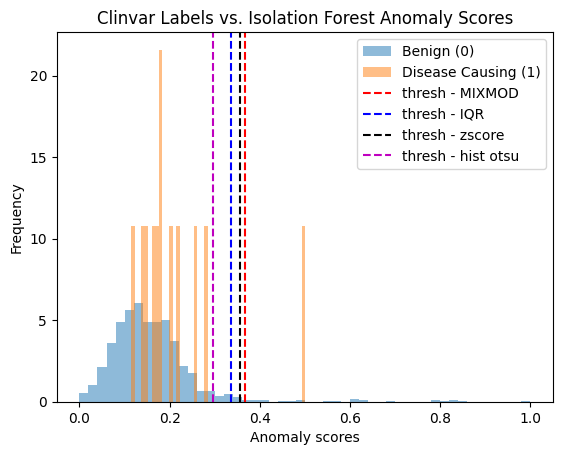

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from pythresh.thresholds.thresh_utility import normalize

#plotting the results

#Normalizing scores
normalized_anomaly_scores = normalize(y_train_scores)
labels = labels_df.to_list()

#Anomaly scores for Benign (0) and Disease Causing (1)
inlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(labels) if label == 0]
outlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(labels) if label == 1]

#Plot histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot thresholds from different methods
plt.axvline(x=thres_mixmod.thresh_, color='r', linestyle='--', label='thresh - MIXMOD')
plt.axvline(x=thres_iqr.thresh_, color='b', linestyle='--', label='thresh - IQR')
plt.axvline(x=thres_zscore.thresh_, color='k', linestyle='--', label='thresh - zscore')
plt.axvline(x=thres_hist.thresh_, color='m', linestyle='--', label='thresh - hist otsu')

plt.xlabel("Anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Clinvar Labels vs. Isolation Forest Anomaly Scores")
plt.show()

## Local Outlier Factor Model

In [32]:
#to run this model all numeric variables will need to be normalized
#most of our variables are binary columns between 0 and 1
#the remaining numeric variables will need to be normalized, also between 0 and 1
#we should be able to do this by min/max normalization

#importing the scaler package
from sklearn.preprocessing import MinMaxScaler

In [33]:
#making a copy dataframe to edit for the LOF model, so we can keep the original Isolation Forest df as is
BRCA_MD2 = BRCA_MD1

#looking over the columns to better select the remaining numeric ones
BRCA_MD2.columns

Index(['call_rate', 'n_het', 'info_AF', 'gvs_all_af', 'gvs_all_sc', 'revel',
       'gvs_max_ac', 'gvs_max_sc', 'gvs_max_an', 'Score(S2)',
       'Sensitivity(S2)', 'FPR Score(S2)', 'Specificity(S2)', 'qc_AF_Ref',
       'qc_AF_Alt', 'ref_allele_A', 'ref_allele_C', 'ref_allele_G',
       'ref_allele_T', 'alt_allele_A', 'alt_allele_C', 'alt_allele_G',
       'alt_allele_T', 'gvs_max_subpop_afr', 'gvs_max_subpop_amr',
       'gvs_max_subpop_eas', 'gvs_max_subpop_eur', 'gvs_max_subpop_mid',
       'gvs_max_subpop_oth', 'gvs_max_subpop_sas', 'Protein_P38398',
       'Protein_P51587', 'Ref_AA_A', 'Ref_AA_C', 'Ref_AA_D', 'Ref_AA_E',
       'Ref_AA_F', 'Ref_AA_G', 'Ref_AA_H', 'Ref_AA_I', 'Ref_AA_K', 'Ref_AA_L',
       'Ref_AA_M', 'Ref_AA_N', 'Ref_AA_P', 'Ref_AA_Q', 'Ref_AA_R', 'Ref_AA_S',
       'Ref_AA_T', 'Ref_AA_V', 'Ref_AA_W', 'Ref_AA_Y', 'Alt_AA_A', 'Alt_AA_C',
       'Alt_AA_D', 'Alt_AA_E', 'Alt_AA_F', 'Alt_AA_G', 'Alt_AA_H', 'Alt_AA_I',
       'Alt_AA_K', 'Alt_AA_L', 'Alt_AA_M', 'Alt_A

In [34]:
#numeric columns to scale
numeric_cols = ['call_rate', 'n_het', 'info_AF', 'gvs_all_af', 'gvs_all_sc', 'revel',
       'gvs_max_ac', 'gvs_max_sc', 'gvs_max_an', 'Score(S2)',
       'Sensitivity(S2)', 'FPR Score(S2)', 'Specificity(S2)', 'qc_AF_Ref',
       'qc_AF_Alt']

#setting the scaler to min/max and transforming the numeric variables
scaler = MinMaxScaler()
BRCA_MD2[numeric_cols] = scaler.fit_transform(BRCA_MD2[numeric_cols])

#checking everything worked properly
BRCA_MD2.head()

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,revel,gvs_max_ac,gvs_max_sc,gvs_max_an,Score(S2),...,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y,(HumDiv) Polyphen Significance(S2)_benign,(HumDiv) Polyphen Significance(S2)_possibly damaging,(HumDiv) Polyphen Significance(S2)_probably damaging
1,0.998743,0.000027,1.224098e-06,0.000001,0.000002,0.724947,0.000000,0.000000,0.110981,0.063,...,0,0,0,0,0,0,0,1,0,0
2,0.997486,0.000081,2.448229e-06,0.000003,0.000005,0.908316,0.000015,0.000026,0.319243,0.997,...,0,0,0,0,0,0,0,0,0,1
3,0.998743,0.000027,3.836096e-11,0.000000,0.000000,0.830490,0.000000,0.000000,0.319252,0.917,...,0,0,0,0,0,0,1,0,1,0
4,0.993715,0.000081,2.448592e-06,0.000003,0.000005,0.855011,0.000015,0.000026,0.319216,0.986,...,0,0,1,0,0,0,0,0,0,1
5,0.998114,0.000027,6.491996e-11,0.000000,0.000000,0.342217,0.000000,0.000000,0.319248,0.875,...,0,0,0,0,0,0,0,0,1,0


In [35]:
#checking all variables are between the range of 0 and 1
BRCA_MD2.describe() #looking at min and max

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,revel,gvs_max_ac,gvs_max_sc,gvs_max_an,Score(S2),...,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y,(HumDiv) Polyphen Significance(S2)_benign,(HumDiv) Polyphen Significance(S2)_possibly damaging,(HumDiv) Polyphen Significance(S2)_probably damaging
count,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,...,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000
mean,0.991238,0.005460,0.002482,0.002482,0.003629,0.372954,0.002370,0.003272,0.318698,0.428240,...,0.024682,0.089172,0.086783,0.069268,0.083599,0.007962,0.039013,0.564490,0.177548,0.257962
std,0.033725,0.060801,0.035351,0.035351,0.044274,0.219821,0.030944,0.034566,0.250402,0.432908,...,0.155214,0.285105,0.281630,0.254010,0.276895,0.088908,0.193702,0.496021,0.382284,0.437687
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.993086,0.000027,0.000001,0.000001,0.000002,0.187367,0.000000,0.000000,0.110981,0.007750,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.996229,0.000054,0.000006,0.000006,0.000012,0.343817,0.000015,0.000026,0.319230,0.209000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.997486,0.000162,0.000028,0.000029,0.000056,0.541844,0.000077,0.000130,0.319257,0.966000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [36]:
#now the the data is normalized we can begin to model
#importing the LOF model from pyod
from pyod.models.lof import LOF

In [ ]:
#setting up the model
lof_mod = LOF(n_neighbors=1000, #nearest neighbors (set super high to actually find anomalies, tried many different values from 10 to 1000)
              contamination=0.01) #proportion of anomalies expected (tried many different prortions from .01 to .5)


#predicting with the LOF model very similar to isolation forest
y_pred_lof = lof_mod.fit(BRCA_MD2)

y_train_scores_lof = lof_mod.decision_scores_  

#setting up the thresholds again
thres_iqr = IQR()
thres_zscore = ZSCORE(factor = 2)
thres_hist = HIST(method='otsu')
thres_mixmod = MIXMOD()

#performing the predictions
y_train_pred_iqr = thres_iqr.eval(y_train_scores_lof)
y_train_pred_zscore = thres_zscore.eval(y_train_scores_lof)
y_train_pred_hist = thres_hist.eval(y_train_scores_lof)
y_train_pred_mixmod = thres_mixmod.eval(y_train_scores_lof)

#creating a classificantion_report breakdown for each threshold
#data labels should be the same
print("IQR thresholding\n===========================================\n")
print(classification_report(labels_df, y_train_pred_iqr, target_names=['normal','anomalies']))
print("zscore thresholding\n============================================\n")
print(classification_report(labels_df, y_train_pred_zscore, target_names=['normal','anomalies']))
print("hist thresholding\n=========================================\n")
print(classification_report(labels_df, y_train_pred_hist, target_names=['normal','anomalies']))
print("MIXMOD thresholding\n=========================================\n")
print(classification_report(labels_df, y_train_pred_mixmod, target_names=['normal','anomalies']))

IQR thresholding

              precision    recall  f1-score   support

      normal       0.99      0.94      0.96      1244
   anomalies       0.03      0.17      0.04        12

    accuracy                           0.93      1256
   macro avg       0.51      0.55      0.50      1256
weighted avg       0.98      0.93      0.96      1256

zscore thresholding

              precision    recall  f1-score   support

      normal       0.99      0.95      0.97      1244
   anomalies       0.03      0.17      0.05        12

    accuracy                           0.94      1256
   macro avg       0.51      0.56      0.51      1256
weighted avg       0.98      0.94      0.96      1256

hist thresholding

              precision    recall  f1-score   support

      normal       1.00      0.89      0.94      1244
   anomalies       0.05      0.58      0.09        12

    accuracy                           0.88      1256
   macro avg       0.52      0.73      0.51      1256
weighted avg    

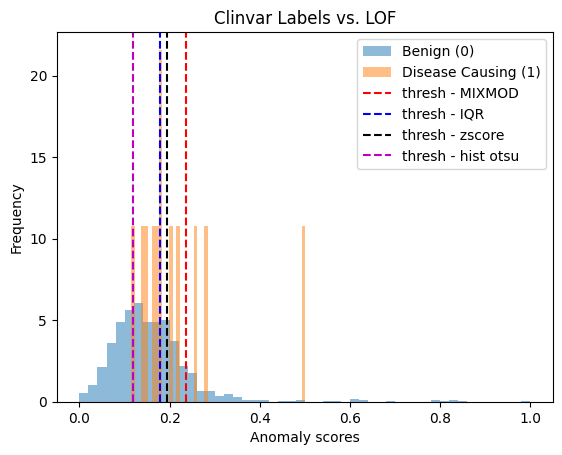

In [38]:
#plotting the results

#Normalizing scores
normalized_anomaly_scores = normalize(y_train_scores)
labels = labels_df.to_list()

#Anomaly scores for Benign (0) and Disease Causing (1)
inlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(labels) if label == 0]
outlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(labels) if label == 1]

#Plot histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot thresholds from different methods
plt.axvline(x=thres_mixmod.thresh_, color='r', linestyle='--', label='thresh - MIXMOD')
plt.axvline(x=thres_iqr.thresh_, color='b', linestyle='--', label='thresh - IQR')
plt.axvline(x=thres_zscore.thresh_, color='k', linestyle='--', label='thresh - zscore')
plt.axvline(x=thres_hist.thresh_, color='m', linestyle='--', label='thresh - hist otsu')

plt.xlabel("Anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Clinvar Labels vs. LOF")
plt.show()

## Setting Threshold manually

In [39]:
#Importing the normalize function, which rescales anomaly decision scores from the model before to the 0–1 range
#Makes thresholds more consistent as it gives a more standard scale, removing ambiguity that can come with negative scores
#Basically making a simple rule‑based classifier built on top of anomaly scores
from pythresh.thresholds.thresh_utility import normalize

#Taking the raw Isolation Forest scores and normalizing them
normalized_if_scores = normalize(y_train_scores)

#Setting a manual threshold based on what I saw in the graphs above
thresh_if = 0.21 #number was determined by looking at the graphs from the previous models

#Applying the threshold to every amomaly score
#If score >= threshold = 1 (anomaly / disease‑causing) or If score < threshold = 0 (normal / benign)
y_pred_if_manual = (normalized_if_scores >= thresh_if).astype(int)

#printing the threshold and the prediction results
print("Isolation Forest - manual threshold =", thresh_if)
print(classification_report(labels_df, y_pred_if_manual, target_names=['normal', 'anomalies']))

Isolation Forest - manual threshold = 0.21
              precision    recall  f1-score   support

      normal       0.99      0.82      0.90      1244
   anomalies       0.02      0.33      0.03        12

    accuracy                           0.81      1256
   macro avg       0.50      0.57      0.46      1256
weighted avg       0.98      0.81      0.89      1256



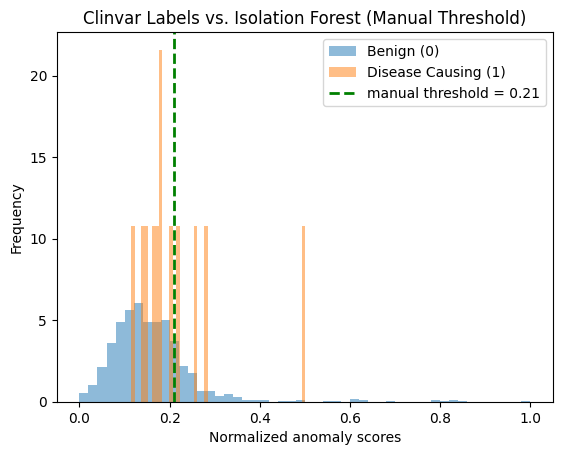

In [40]:
#Plotting the distribution of scores with the manual threshold

#Converting the labels to a list for plotting
labels = labels_df.to_list()

#Splitting scores by ClinVar label Other (0) and Disease Causing (1)
inlier_scores = [normalized_if_scores[i] for i, label in enumerate(labels) if label == 0]
outlier_scores = [normalized_if_scores[i] for i, label in enumerate(labels) if label == 1]

#Manually set threshold
thresh_if = 0.21

#Plotting histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

# Plot manual threshold
plt.axvline(x=thresh_if, color='g', linestyle='--', linewidth=2,
            label=f'manual threshold = {thresh_if}')

plt.xlabel("Normalized anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Clinvar Labels vs. Isolation Forest (Manual Threshold)")
plt.show()

In [41]:
#Doing another manual threshold with the Local Outlier Factor Model
#Normalizing the LOF anomaly decision scores from the LOF model before
normalized_lof_scores = normalize(y_train_scores_lof)

#manual threshold after looking at the graph
thresh_lof = 0.1

#same as the previous manual model, its a rule based classifier
#If score >= threshold = 1 (anomaly / disease‑causing) or If score < threshold = 0 (normal / benign)
y_pred_lof_manual = (normalized_lof_scores >= thresh_lof).astype(int)

#printing results
print("LOF - manual threshold =", thresh_lof)
print(classification_report(labels_df, y_pred_lof_manual,
                            target_names=['normal', 'anomalies']))

LOF - manual threshold = 0.1
              precision    recall  f1-score   support

      normal       1.00      0.83      0.90      1244
   anomalies       0.04      0.75      0.08        12

    accuracy                           0.83      1256
   macro avg       0.52      0.79      0.49      1256
weighted avg       0.99      0.83      0.90      1256



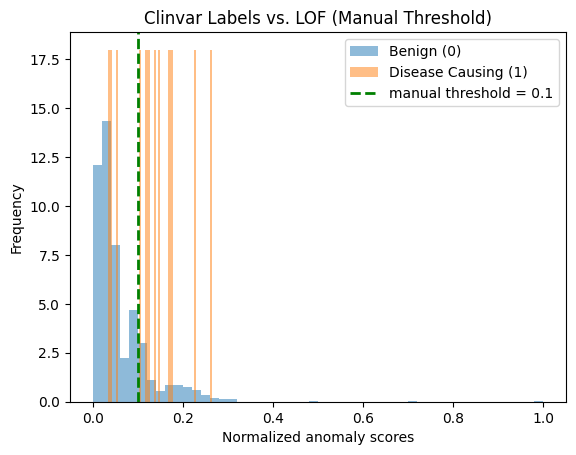

In [42]:
#plotting the results 

#Converting labels to list
labels = labels_df.to_list()

#Splitting LOF scores by ClinVar label
inlier_scores_lof = [normalized_lof_scores[i] for i, label in enumerate(labels) if label == 0]
outlier_scores_lof = [normalized_lof_scores[i] for i, label in enumerate(labels) if label == 1]

#Manual threshold
thresh_lof = 0.1

#Plotting histograms
plt.hist(inlier_scores_lof, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores_lof, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot manual threshold line
plt.axvline(x=thresh_lof, color='g', linestyle='--', linewidth=2,
            label=f'manual threshold = {thresh_lof}')

plt.xlabel("Normalized anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Clinvar Labels vs. LOF (Manual Threshold)")
plt.show()

#graph major difference explained
#When you normalize LOF scores: the long tail gets stretched, the dense cluster gets compressed, and 
#the distribution becomes more visibly skewed